# EDA und Datenvorbereitung

Ziel dieses Notebooks ist es, die Data-Collection-Outputs zu verstehen, erste Qualitätschecks durchzuführen und die Datasets für die Analyse vorzubereiten

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
# Use "notebook+png" instead of "png" for interactive charts (not supported on GitHub)
# pio.renderers.default = "notebook+png"
pio.renderers.default = "png"


In [84]:
DATA_DIR = Path("../../data")
INTERIM_DIR = DATA_DIR / "interim"

In [85]:
COSTS_FILE = INTERIM_DIR / "gesundheitskosten_2011_2026.csv"

df_costs = pd.read_csv(COSTS_FILE)

print(pd.DataFrame({
        "rows": [len(df_costs)],
        "columns": [df_costs.shape[1]],
        "duplicate_rows": [df_costs.duplicated().sum()],
        "missing_cells": [df_costs.isna().sum().sum()],
}))
empty_columns = df_costs.columns[df_costs.isna().all()].tolist()
print(empty_columns)

   rows  columns  duplicate_rows  missing_cells
0  7939       42               0         111146
['Time Period', 'Observation value (DotStat)', 'DIFF_REGION_STATE', 'Date of spatial reference', 'DIFF_LAST_UPDATE', 'Update date', 'DIFF_EMBARGO_DATE', 'Date of publication', 'DIFF_DB_STATE', 'Database state', 'OBS_STATUS', 'Code list for Observation Status', 'DIFF_REGION_REF', 'Spatial reference']


Die Gesundheitskosten enthalten 44’232 fehlende Werte. Diese entstehen  durch sechs optionale Metadatenspalten die leer sind. Die analyse-relevanten Spalten wie Jahr, Kanton, Alter, Beobachtungswert, Multiplikator und Status enthalten keine fehlenden Werte.

Es sind ebenfalls viele Spalten vorhanden, welche für die Analyse später nicht relevant sind.

In [86]:
cost_columns = [
    "TIME_PERIOD",
    "CANTON",
    "Swiss cantons",
    "AGE",
    "Age groups",
    "OBS_VALUE",
    "MULT",
    "OBS_STATUS",
    "Code list for Observation Status",
]

df_costs_processed = df_costs[cost_columns].copy()
df_costs_processed.head(30)

,TIME_PERIOD,CANTON,Swiss cantons,AGE,Age groups,OBS_VALUE,MULT,OBS_STATUS,Code list for Observation Status
0,2011,_T,Total,_T,Total,64234.605,6,NaN,NaN
1,2012,_T,Total,_T,Total,66521.484,6,NaN,NaN
2,2013,_T,Total,_T,Total,69352.480,6,NaN,NaN
3,2014,_T,Total,_T,Total,71055.555,6,NaN,NaN
4,2015,_T,Total,_T,Total,73345.970,6,NaN,NaN
5,2016,_T,Total,_T,Total,75935.875,6,NaN,NaN
6,2017,_T,Total,_T,Total,77866.586,6,NaN,NaN
7,2018,_T,Total,_T,Total,79171.640,6,NaN,NaN
8,2019,_T,Total,_T,Total,81686.110,6,NaN,NaN
9,2020,_T,Total,_T,Total,83522.010,6,NaN,NaN


In [87]:
pd.DataFrame({
        "year_min": [df_costs_processed["TIME_PERIOD"].min()],
        "year_max": [df_costs_processed["TIME_PERIOD"].max()],
        "n_years": [df_costs_processed["TIME_PERIOD"].nunique()],
        "n_cantons": [df_costs_processed["Swiss cantons"].nunique()],
        "n_age_groups": [df_costs_processed["Age groups"].nunique()],
        "n_status": [df_costs_processed["OBS_STATUS"].nunique()],
        "n_multipliers": [df_costs_processed["MULT"].nunique()],
})

,year_min,year_max,n_years,n_cantons,n_age_groups,n_status,n_multipliers
0,2011,2025,15,27,21,0,1


In [88]:
print(f'Status: \n {df_costs_processed["OBS_STATUS"].unique()}')
print(f'Kantone: \n {df_costs_processed["Swiss cantons"].unique()}')

Status: 
 [nan]
Kantone: 
 <StringArray>
[                 'Total',                 'Zurich',                   'Bern',
                'Lucerne',                    'Uri',                 'Schwyz',
               'Obwalden',              'Nidwalden',                 'Glarus',
                    'Zug',               'Fribourg',              'Solothurn',
            'Basel-Stadt',       'Basel-Landschaft',           'Schaffhausen',
 'Appenzell Ausserrhoden',  'Appenzell Innerrhoden',             'St. Gallen',
             'Graubünden',                 'Aargau',                'Thurgau',
                 'Ticino',                   'Vaud',                 'Valais',
              'Neuchâtel',                 'Geneva',                   'Jura']
Length: 27, dtype: str


In [89]:
pd.crosstab(
    df_costs_processed["TIME_PERIOD"],
    df_costs_processed["OBS_STATUS"]
)

OBS_STATUS
TIME_PERIOD


Für den Status haben 3 verschiedene Werte:

- A: Normaler Wert
- E: Geschätzter Wert
- P: Provisorischer Wert

Das Jahr 2023 beinhaltet nur provisorische Werte für alle Zeilen.
Das Jahr 2024 beinhaltet insgesamt nur einen geschätzten Wert.

Die Spalte Kantone beinhaltet alle 26 Kantone und das Total für die Schweiz

Um den absolut Wert für die Kosten zu erhalten müssen wird eine zusätzliche Spalte einfügen

In [90]:
df_costs_processed["costs_chf"] = df_costs["OBS_VALUE"] * (10 ** df_costs["MULT"])
df_costs_processed.head()

,TIME_PERIOD,CANTON,Swiss cantons,AGE,Age groups,OBS_VALUE,MULT,OBS_STATUS,Code list for Observation Status,costs_chf
0,2011,_T,Total,_T,Total,64234.605,6,NaN,NaN,6.423460e+10
1,2012,_T,Total,_T,Total,66521.484,6,NaN,NaN,6.652148e+10
2,2013,_T,Total,_T,Total,69352.480,6,NaN,NaN,6.935248e+10
3,2014,_T,Total,_T,Total,71055.555,6,NaN,NaN,7.105556e+10
4,2015,_T,Total,_T,Total,73345.970,6,NaN,NaN,7.334597e+10


Die Spalten sollten für einfacheres handling umbenennt werden.

In [91]:
df_costs_processed = df_costs_processed.rename(columns={
    "TIME_PERIOD": "year",
    "CANTON": "canton_label",
    "Swiss cantons": "cantons",
    "AGE": "age_label",
    "Age groups": "age",
    "OBS_VALUE": "cost_raw",
    "MULT": "mult",
    "OBS_STATUS": "cost_status_label",
    "Code list for Observation Status": "cost_status",
})
df_costs_processed.head()

,year,canton_label,cantons,age_label,age,cost_raw,mult,cost_status_label,cost_status,costs_chf
0,2011,_T,Total,_T,Total,64234.605,6,NaN,NaN,6.423460e+10
1,2012,_T,Total,_T,Total,66521.484,6,NaN,NaN,6.652148e+10
2,2013,_T,Total,_T,Total,69352.480,6,NaN,NaN,6.935248e+10
3,2014,_T,Total,_T,Total,71055.555,6,NaN,NaN,7.105556e+10
4,2015,_T,Total,_T,Total,73345.970,6,NaN,NaN,7.334597e+10


In [92]:
# Use Series.replace(CANTON_NORMALIZE) to unify canton names.
CANTON_NORMALIZE = {
    # costs CSV (English)
    "Zurich": "Zürich",
    "Lucerne": "Luzern",
    "Geneva": "Genève",
    # population CSV (multi-language)
    "Bern / Berne": "Bern",
    "Fribourg / Freiburg": "Fribourg",
    "Graubünden / Grigioni / Grischun": "Graubünden",
    "Valais / Wallis": "Valais",
    # 2-letter ICC codes (praemien)
    "ZH": "Zürich",  "BE": "Bern",  "LU": "Luzern",  "UR": "Uri",
    "SZ": "Schwyz",  "OW": "Obwalden",  "NW": "Nidwalden",  "GL": "Glarus",
    "ZG": "Zug",  "FR": "Fribourg",  "SO": "Solothurn",  "BS": "Basel-Stadt",
    "BL": "Basel-Landschaft",  "SH": "Schaffhausen",
    "AR": "Appenzell Ausserrhoden",  "AI": "Appenzell Innerrhoden",
    "SG": "St. Gallen",  "GR": "Graubünden",  "AG": "Aargau",
    "TG": "Thurgau",  "TI": "Ticino",  "VD": "Vaud",
    "VS": "Valais",  "NE": "Neuchâtel",  "GE": "Genève",  "JU": "Jura",
}

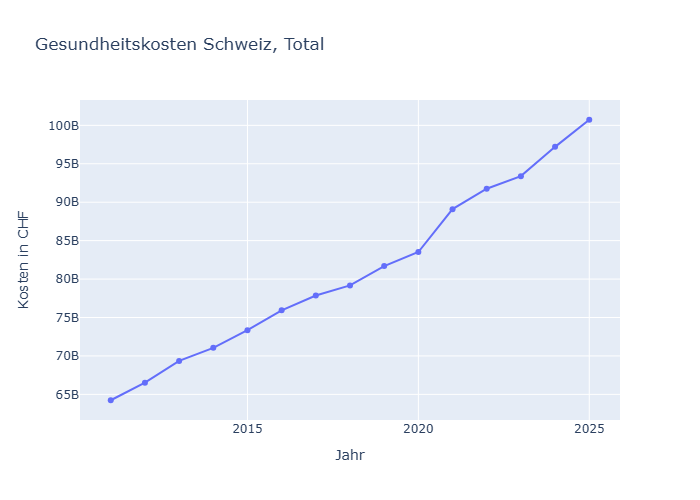

In [93]:
df_costs_total_ch = df_costs_processed[
    (df_costs_processed["cantons"] == "Total") &
    (df_costs_processed["age"] == "Total")
].copy()

px.line(
    df_costs_total_ch,
    x="year",
    y="costs_chf",
    markers=True,
    title="Gesundheitskosten Schweiz, Total",
    labels={"year": "Jahr", "costs_chf": "Kosten in CHF"},
)

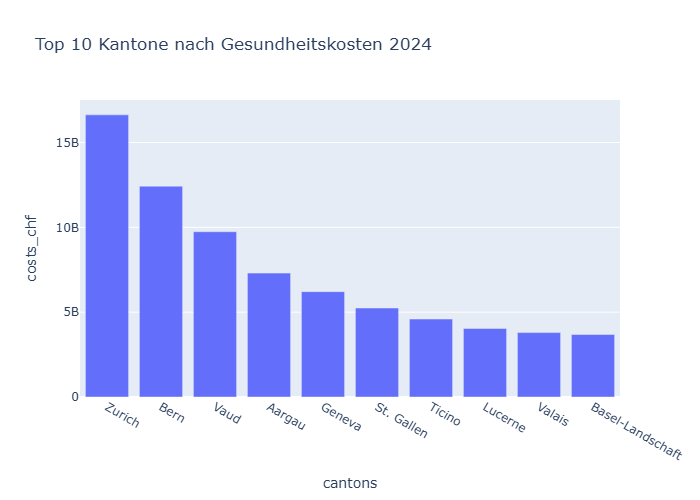

In [94]:
df_costs_canton_total = df_costs_processed[
    (df_costs_processed["age"] == "Total") &
    (df_costs_processed["cantons"] != "Total")
].copy()

latest_canton_year = int(df_costs_canton_total["year"].max())

df_costs_canton_latest = (
    df_costs_canton_total[df_costs_canton_total["year"] == latest_canton_year]
    .sort_values("costs_chf", ascending=False)
)

px.bar(
    df_costs_canton_latest.head(10),
    x="cantons",
    y="costs_chf",
    title=f"Top 10 Kantone nach Gesundheitskosten {latest_canton_year}",
)

Im Plot für die Top 10 Kantone ist zu sehen, dass die Bevölkerungsgrösse eine Rolle spielt.

Für die spätere Analyse könnten die pro Kopf Kosten einen besseren Einblick geben

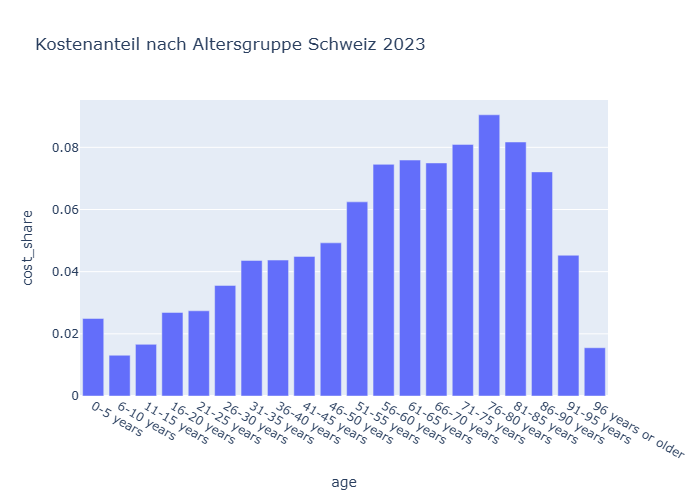

In [95]:
df_costs_age_ch = df_costs_processed[
    (df_costs_processed["cantons"] == "Total") &
    (df_costs_processed["age"] != "Total") &
    (df_costs_processed["year"] == 2023)
].copy()

df_costs_age_ch["cost_share"] = (
    df_costs_age_ch["costs_chf"] / df_costs_age_ch["costs_chf"].sum()
)

px.bar(
    df_costs_age_ch,
    x="age",
    y="cost_share",
    title="Kostenanteil nach Altersgruppe Schweiz 2023",
)

In [96]:
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

df_costs_processed["cantons"] = df_costs_processed["cantons"].replace(CANTON_NORMALIZE)
df_costs_processed.to_csv(PROCESSED_DIR / "gesundheitskosten.csv", index=False)

In [97]:
# Names and abbreviation of cantons
df_kantone = pd.DataFrame(
    [{"canton": canton, "icc": icc} for icc, canton in CANTON_NORMALIZE.items() if len(icc) == 2]
).sort_values("canton").reset_index(drop=True)

df_kantone.to_csv(PROCESSED_DIR / "kantone.csv", index=False)
df_kantone

,canton,icc
0,Aargau,AG
1,Appenzell Ausserrhoden,AR
2,Appenzell Innerrhoden,AI
3,Basel-Landschaft,BL
4,Basel-Stadt,BS
5,Bern,BE
6,Fribourg,FR
7,Genève,GE
8,Glarus,GL
9,Graubünden,GR


# 2. Bevölkerung

In [98]:
POPULATION_FILE = INTERIM_DIR / "bevoelkerung_2011_2026.csv"

df_population = pd.read_csv(POPULATION_FILE)
pd.DataFrame({
        "rows": [len(df_population)],
        "columns": [df_population.shape[1]],
        "duplicate_rows": [df_population.duplicated().sum()],
        "missing_cells": [df_population.isna().sum().sum()],
})

,rows,columns,duplicate_rows,missing_cells
0,39984,6,0,0


In [99]:
df_population.head()

,Jahr,Kanton,Staatsangehörigkeit (Kategorie),Geschlecht,Alter,Bestand am 31. Dezember
0,2011,Schweiz,Staatsangehörigkeit (Kategorie) - Total,Geschlecht - Total,Alter - Total,7954662
1,2011,Schweiz,Staatsangehörigkeit (Kategorie) - Total,Geschlecht - Total,0 Jahre,78426
2,2011,Schweiz,Staatsangehörigkeit (Kategorie) - Total,Geschlecht - Total,1 Jahr,81663
3,2011,Schweiz,Staatsangehörigkeit (Kategorie) - Total,Geschlecht - Total,2 Jahre,80196
4,2011,Schweiz,Staatsangehörigkeit (Kategorie) - Total,Geschlecht - Total,3 Jahre,79522


In [100]:
print(df_population["Staatsangehörigkeit (Kategorie)"].unique())
print(df_population["Geschlecht"].unique())

<StringArray>
['Staatsangehörigkeit (Kategorie) - Total']
Length: 1, dtype: str
<StringArray>
['Geschlecht - Total']
Length: 1, dtype: str


Die Spalten Staatsangehörige und Geschlecht enthalten für alle Zeilen die selben Werte. Für die weitere Analyse sind diese nicht von Bedeutung.

In [101]:
df_population_processed = df_population.drop(columns=["Staatsangehörigkeit (Kategorie)", "Geschlecht"])
print(pd.DataFrame({
        "rows": [len(df_population_processed)],
        "columns": [df_population_processed.shape[1]],
}))

    rows  columns
0  39984        4


Für eine spätere Analyse kann es sinnvoll sein das Alter als einen numerischen Typ zu haben

In [102]:
df_population_processed.rename(columns={
    "Alter": "alter_label",
}, inplace=True)
df_population_processed["alter"] = df_population_processed["alter_label"].str.extract(r"(\d+)").astype("float")
df_population_processed.head()

,Jahr,Kanton,alter_label,Bestand am 31. Dezember,alter
0,2011,Schweiz,Alter - Total,7954662,NaN
1,2011,Schweiz,0 Jahre,78426,0.0
2,2011,Schweiz,1 Jahr,81663,1.0
3,2011,Schweiz,2 Jahre,80196,2.0
4,2011,Schweiz,3 Jahre,79522,3.0


Für eingacheres handling macht es Sinn die Spalten umzubennen.

In [103]:
df_population_processed = df_population_processed.rename(columns={
    "Jahr": "year",
    "Kanton": "canton",
    "alter_label": "age_label",
    "Bestand am 31. Dezember": "population",
    "alter": "age",
})
df_population_processed.head()

,year,canton,age_label,population,age
0,2011,Schweiz,Alter - Total,7954662,NaN
1,2011,Schweiz,0 Jahre,78426,0.0
2,2011,Schweiz,1 Jahr,81663,1.0
3,2011,Schweiz,2 Jahre,80196,2.0
4,2011,Schweiz,3 Jahre,79522,3.0


In [104]:
pd.DataFrame({
        "year_min": [df_population_processed["year"].min()],
        "year_max": [df_population_processed["year"].max()],
        "n_years": [df_population_processed["year"].nunique()],
        "n_cantons": [df_population_processed["canton"].nunique()],
        "n_age_groups": [df_population_processed["age_label"].nunique()],
})

,year_min,year_max,n_years,n_cantons,n_age_groups
0,2011,2024,14,28,102


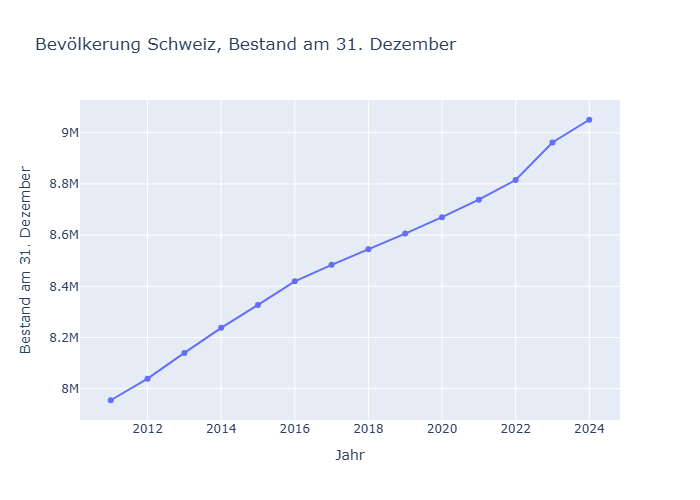

In [105]:
df_population_ch = df_population_processed[
    (df_population_processed["canton"] == "Schweiz") &
    (df_population_processed["age_label"].eq("Alter - Total"))
].copy()

px.line(
    df_population_ch,
    x="year",
    y="population",
    markers=True,
    title="Bevölkerung Schweiz, Bestand am 31. Dezember",
    labels={"year": "Jahr", "population": "Bestand am 31. Dezember"},
)

In [106]:
df_ch = df_population_processed[df_population_processed["canton"] == "Schweiz"]

official_total = df_ch[df_ch["age_label"] == "Alter - Total"].set_index("year")["population"]

age_sum = (
    df_ch[df_ch["age_label"] != "Alter - Total"]
    .groupby("year")["population"]
    .sum()
)

(age_sum - official_total).abs().max()

np.int64(0)

In [107]:
df_population_age = df_population_processed[df_population_processed["age_label"] != "Alter - Total"].copy()
df_population_age["is_66_plus"] = df_population_age["age"] >= 66

df_population_66_share = (
    df_population_age
    .groupby(["year", "canton", "is_66_plus"], as_index=False)["population"]
    .sum()
)

df_population_66_share["total_population"] = df_population_66_share.groupby(["year", "canton"])["population"].transform("sum")
df_population_66_share["population_share_66_plus"] = df_population_66_share["population"] / df_population_66_share["total_population"]
df_population_66_share = df_population_66_share[df_population_66_share["is_66_plus"]].copy()

df_population_66_share.head()

,year,canton,is_66_plus,population,total_population,population_share_66_plus
1,2011,Aargau,True,91306,618298,0.147673
3,2011,Appenzell Ausserrhoden,True,8947,53313,0.167820
5,2011,Appenzell Innerrhoden,True,2525,15743,0.160389
7,2011,Basel-Landschaft,True,51472,275360,0.186926
9,2011,Basel-Stadt,True,36629,186255,0.196660


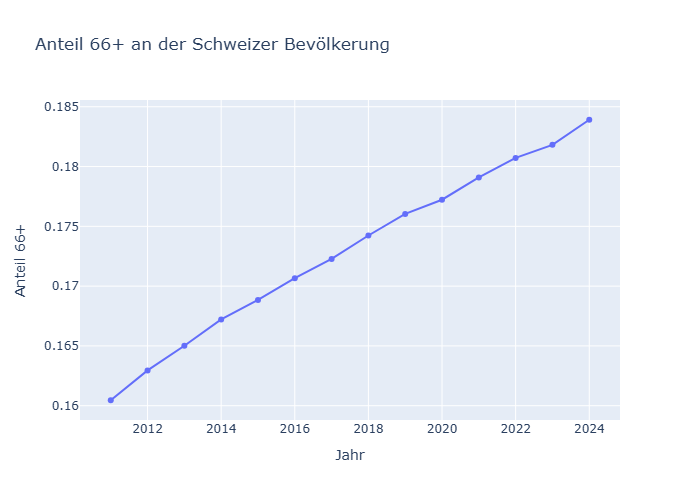

In [108]:
px.line(
    df_population_66_share[df_population_66_share["canton"] == "Schweiz"],
    x="year",
    y="population_share_66_plus",
    markers=True,
    title="Anteil 66+ an der Schweizer Bevölkerung",
    labels={"year": "Jahr", "population_share_66_plus": "Anteil 66+"},
)

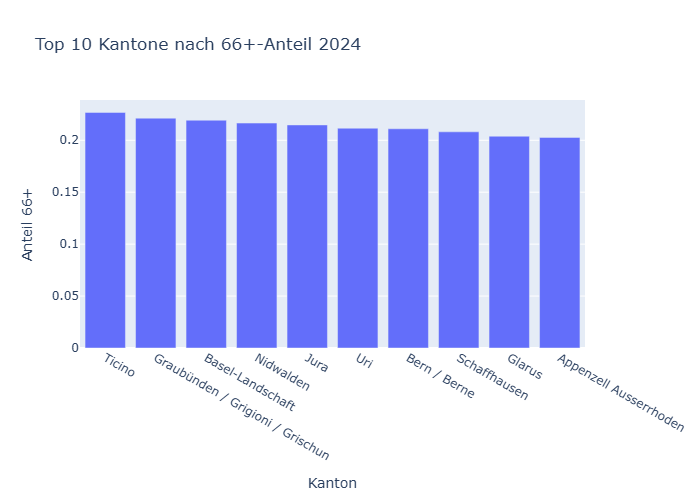

In [109]:
latest_population_year = df_population_66_share["year"].max()

df_population_66_latest = (
    df_population_66_share[
        (df_population_66_share["year"] == latest_population_year) &
        (~df_population_66_share["canton"].isin(["Schweiz"]))
    ]
    .sort_values("population_share_66_plus", ascending=False)
)

px.bar(
    df_population_66_latest.head(10),
    x="canton",
    y="population_share_66_plus",
    title=f"Top 10 Kantone nach 66+-Anteil {latest_population_year}",
    labels={"canton": "Kanton", "population_share_66_plus": "Anteil 66+"},
)

In [110]:
df_population_processed["canton"] = df_population_processed["canton"].replace(CANTON_NORMALIZE)
df_population_66_share["canton"] = df_population_66_share["canton"].replace(CANTON_NORMALIZE)

df_population_processed.to_csv(PROCESSED_DIR / "bevoelkerung.csv", index=False)
df_population_66_share.to_csv(PROCESSED_DIR / "bevoelkerung_66_share.csv", index=False)

## Prämien

Die Prämien liegen in drei historischen Schemas vor. Für die EDA wird eine gemeinsame Minimalansicht erstellt.

In [111]:
PREMIUM_FILES = {
    "2011_2014": INTERIM_DIR / "premium_2011_2014.csv",
    "2015_2016": INTERIM_DIR / "premium_2015_2016.csv",
    "2017_2026": INTERIM_DIR / "premium_2017_2026.csv",
}
df_11_14 = pd.read_csv(PREMIUM_FILES["2011_2014"])
df_15_16 = pd.read_csv(PREMIUM_FILES["2015_2016"])
df_17_26 = pd.read_csv(PREMIUM_FILES["2017_2026"])

pd.concat([
        pd.DataFrame({
            "rows": [len(df_11_14)],
            "columns": [df_11_14.shape[1]],
            "duplicate_rows": [df_11_14.duplicated().sum()],
            "missing_cells": [df_11_14.isna().sum().sum()],
        }),
        pd.DataFrame({
            "rows": [len(df_15_16)],
            "columns": [df_15_16.shape[1]],
            "duplicate_rows": [df_15_16.duplicated().sum()],
            "missing_cells": [df_15_16.isna().sum().sum()],
        }),
        pd.DataFrame({
            "rows": [len(df_17_26)],
            "columns": [df_17_26.shape[1]],
            "duplicate_rows": [df_17_26.duplicated().sum()],
            "missing_cells": [df_17_26.isna().sum().sum()],
        })
    ]
)

,rows,columns,duplicate_rows,missing_cells
0,1164000,23,0,2958
0,531208,18,0,1383364
0,2508844,18,0,1449204


In [112]:
def missing_by_column(df):
    return (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame("missing_count")
    )

for name, df in {
    "2011_2014": df_11_14,
    "2015_2016": df_15_16,
    "2017_2026": df_17_26,
}.items():
    print(name)
    display(missing_by_column(df).head(10))

2011_2014


,missing_count
m_id,174
r_id,174
jahr,174
isbase_v2,174
v_typ,174
v_id,174
var_id,174
f_stufe,174
f,174
p,174


2015_2016


,missing_count
sort,531208
tarifbezeichnung,531208
altersuntergruppe,320948
versicherer,0
kanton,0
geschaeftsjahr,0
altersklasse,0
unfalleinschluss,0
region,0
erhebungsjahr,0


2017_2026


,missing_count
altersuntergruppe,1449204
versicherer,0
kanton,0
hoheitsgebiet,0
erhebungsjahr,0
geschaeftsjahr,0
altersklasse,0
unfalleinschluss,0
tarif,0
region,0


In [113]:
df_11_14[df_11_14["isbase_p"].isna()].head()

,g_id,c_id,c_grp,ejahr,jahr,r_id,m_id,var_id,v_id,v_typ,...,isbase_p,isbase_f,f_stufe,f,p,v_sort_nr,v_kbez,isbase_v,isttaetig,jahr_import
6876,8,CH,CH,2010,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2011
10525,32,CH,CH,2010,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2011
12906,57,CH,CH,2010,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2011
14959,62,CH,CH,2010,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2011
22106,160,CH,CH,2010,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2011


In [114]:
df_11_14[df_11_14["isbase_p"].isna()]["jahr_import"].value_counts()


jahr_import
2011    53
2012    41
2013    40
2014    40
Name: count, dtype: int64

Bei den Fehlenden Werten handelt es sich um solche welche für die Spätere Analyse benötigt werden. Das es aber nur sehr wenige sind können diese problemlos entfern werden.

In [115]:
premium_2011_2014_columns = [
    "jahr_import",
    "c_id",
    "v2_typ",
    "isbase_p",
    "isbase_f",
    "f",
    "p",
]

df_11_14_missing_required = df_11_14[
    df_11_14[premium_2011_2014_columns].isna().any(axis=1)
].copy()

df_11_14_missing_required["jahr_import"].value_counts().sort_index()

jahr_import
2011    53
2012    41
2013    40
2014    40
Name: count, dtype: int64

In [116]:
df_11_14_processed = df_11_14.dropna(
    subset=premium_2011_2014_columns
).copy()

print(f"Verbleibende Zeilen: {len(df_11_14_processed)}")

Verbleibende Zeilen: 1163826


In [117]:
df_11_14_processed = pd.DataFrame({
            "year": pd.to_numeric(df_11_14_processed["jahr_import"], errors="coerce"),
            "canton_code": df_11_14_processed["c_id"],
            "age_class": df_11_14_processed["v2_typ"],
            "premium": pd.to_numeric(df_11_14_processed["p"], errors="coerce"),
            "franchise": pd.to_numeric(df_11_14_processed["f"], errors="coerce"),
            "is_base_p": pd.to_numeric(df_11_14_processed["isbase_p"], errors="coerce"),
            "is_base_f": pd.to_numeric(df_11_14_processed["isbase_f"], errors="coerce"),
            "source_schema": "2011-2014",
        })

df_11_14_processed.head()

,year,canton_code,age_class,premium,franchise,is_base_p,is_base_f,source_schema
0,2011,AG,K,69.0,200.0,0.0,0.0,2011-2014
1,2011,AG,K,63.5,300.0,0.0,0.0,2011-2014
2,2011,AG,E,250.8,1000.0,0.0,0.0,2011-2014
3,2011,AG,K,74.4,100.0,0.0,0.0,2011-2014
4,2011,AG,J,230.5,300.0,0.0,1.0,2011-2014


In [118]:
df_15_16_processed = pd.DataFrame({
        "year": pd.to_numeric(df_15_16["geschaeftsjahr"], errors="coerce"),
        "canton_code": df_15_16["kanton"],
        "age_class": df_15_16["altersklasse"],
        "premium": pd.to_numeric(df_15_16["praemie"], errors="coerce"),
        "franchise": df_15_16["franchise"],
        "is_base_p": pd.to_numeric(df_15_16["isbasep"], errors="coerce"),
        "is_base_f": pd.to_numeric(df_15_16["isbasef"], errors="coerce"),
        "source_schema": "2015-2016",
    })
df_15_16_processed.head()

,year,canton_code,age_class,premium,franchise,is_base_p,is_base_f,source_schema
0,2015,AG,AKL-KIN,84.3,FRA-0,1,1,2015-2016
1,2015,AG,AKL-KIN,78.5,FRA-100,1,0,2015-2016
2,2015,AG,AKL-KIN,72.7,FRA-200,1,0,2015-2016
3,2015,AG,AKL-KIN,66.8,FRA-300,1,0,2015-2016
4,2015,AG,AKL-KIN,61.0,FRA-400,1,0,2015-2016


In [119]:
df_17_26_processed = pd.DataFrame({
        "year": pd.to_numeric(df_17_26["geschaeftsjahr"], errors="coerce"),
        "canton_code": df_17_26["kanton"],
        "age_class": df_17_26["altersklasse"],
        "premium": pd.to_numeric(df_17_26["praemie"], errors="coerce"),
        "franchise": df_17_26["franchise"],
        "is_base_p": pd.to_numeric(df_17_26["isbasep"], errors="coerce"),
        "is_base_f": pd.to_numeric(df_17_26["isbasef"], errors="coerce"),
        "source_schema": "2017-2026",
    })
df_17_26_processed.head()

,year,canton_code,age_class,premium,franchise,is_base_p,is_base_f,source_schema
0,2017,AG,AKL-KIN,77.4,FRA-0,0,1,2017-2026
1,2017,AG,AKL-KIN,71.6,FRA-100,0,0,2017-2026
2,2017,AG,AKL-KIN,65.8,FRA-200,0,0,2017-2026
3,2017,AG,AKL-KIN,59.9,FRA-300,0,0,2017-2026
4,2017,AG,AKL-KIN,54.1,FRA-400,0,0,2017-2026


In [120]:
df_premiums = pd.concat([
    df_11_14_processed,
    df_15_16_processed,
    df_17_26_processed,
])
df_premiums.head()

,year,canton_code,age_class,premium,franchise,is_base_p,is_base_f,source_schema
0,2011,AG,K,69.0,200.0,0.0,0.0,2011-2014
1,2011,AG,K,63.5,300.0,0.0,0.0,2011-2014
2,2011,AG,E,250.8,1000.0,0.0,0.0,2011-2014
3,2011,AG,K,74.4,100.0,0.0,0.0,2011-2014
4,2011,AG,J,230.5,300.0,0.0,1.0,2011-2014


In [121]:
pd.DataFrame({
    "year_min": [df_premiums["year"].min()],
    "year_max": [df_premiums["year"].max()],
    "n_years": [df_premiums["year"].nunique()],
    "n_cantons": [df_premiums["canton_code"].nunique()],
    "n_age_classes": [df_premiums["age_class"].nunique()],
    "missing_premium": [df_premiums["premium"].isna().mean()],
})

,year_min,year_max,n_years,n_cantons,n_age_classes,missing_premium
0,2011,2026,16,28,6,0.0


Wir vergleichen nur die Standardprämien und Franchise

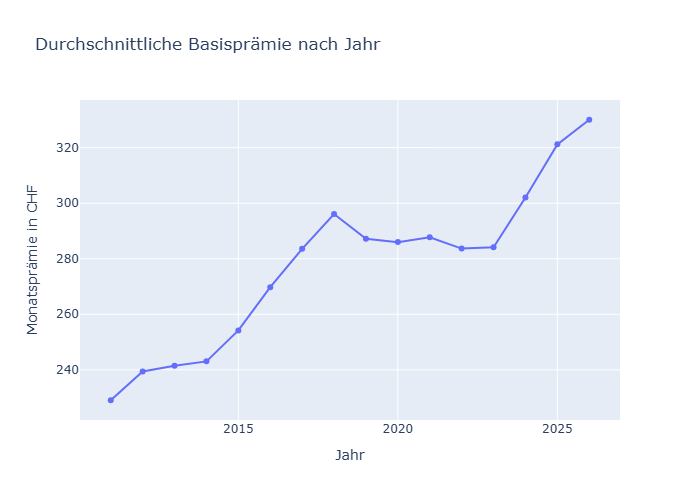

In [122]:
df_premiums_base = df_premiums[
    (df_premiums["is_base_p"] == 1) &
    (df_premiums["is_base_f"] == 1)]

premium_year = (
    df_premiums_base
    .groupby("year", as_index=False)["premium"]
    .mean()
)

px.line(
    premium_year,
    x="year",
    y="premium",
    markers=True,
    title="Durchschnittliche Basisprämie nach Jahr",
    labels={"year": "Jahr", "premium": "Monatsprämie in CHF"},
)

In [123]:
df_premiums["canton"] = df_premiums["canton_code"].replace(CANTON_NORMALIZE)
df_premiums_base["canton"] = df_premiums_base["canton_code"].replace(CANTON_NORMALIZE)

df_premiums.to_csv(PROCESSED_DIR / "praemien.csv", index=False)
df_premiums_base.to_csv(PROCESSED_DIR / "praemien_base.csv", index=False)